# Plot

In [12]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata
import scipy.ndimage as ndimage
from matplotlib.colors import LogNorm
import json

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disabpd.option_context('display.max_columns', 300)le copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Load NLO cross-sections

In [13]:
xsecs_c1c1 = np.genfromtxt('xsec_13TeV_pp2chgchg_fb.csv',delimiter=',',names=True)
xsecs_c1n1 = np.genfromtxt('xsec_13TeV_pp2chgn1_fb.csv',delimiter=',',names=True)

def xsc1c1(mLLP):
    xs = np.interp(mLLP, xsecs_c1c1['mass'], xsecs_c1c1['xsec'])
    return float(xs)

def xsc1n1(mLLP):
    xs = np.interp(mLLP, xsecs_c1n1['mass'], xsecs_c1n1['xsec'])
    return float(xs)


def getRvalue(mLLP,eff_c1c1,eff_c1n1):
    xs_c1c1 = xsc1c1(mLLP)
    xs_c1n1 = xsc1n1(mLLP)
    xs_visible = (eff_c1c1*xs_c1c1 + eff_c1n1*xs_c1n1)
    sigma_UL_atlas_fb = 0.037
    r = xs_visible/sigma_UL_atlas_fb

    return r
    

### Load ATLAS official exclusion curve

In [32]:
atlas_official = list(np.genfromtxt('official_exclusion.txt',delimiter=';'))
atlas_official = sorted(atlas_official, key = lambda x: x[1])
atlas_official = np.array(atlas_official)

### Create dataframe with all results

In [15]:
# Load JSON
with open('chgchg_effs_new.json') as f:
    dataList = json.load(f)
rows = []
for i,data in enumerate(dataList):
    # Separate scalar fields and list-of-dicts fields
    scalar_fields = {k: v for k, v in data.items() if not isinstance(v, list)}
    list_fields   = {k: v for k, v in data.items() if isinstance(v, list)}

    for field, listOfDicts in list_fields.items():
        for d in listOfDicts:            
            row = scalar_fields.copy()
            row["index"] = i
            row.update(d)
            rows.append(row)

# Convert to DataFrame
df_c1c1 = pd.DataFrame(rows)
column_order = ['mLLP','tau_ns','tau0_ns']
column_order = column_order[:] + [col for col in df_c1c1.columns if col not in column_order[:]]

# Optional: set MultiIndex
df_c1c1 = df_c1c1[column_order]

with open('chgn1_effs_new.json') as f:
    dataList = json.load(f)
rows = []
for i,data in enumerate(dataList):
    # Separate scalar fields and list-of-dicts fields
    scalar_fields = {k: v for k, v in data.items() if not isinstance(v, list)}
    list_fields   = {k: v for k, v in data.items() if isinstance(v, list)}

    for field, listOfDicts in list_fields.items():
        for d in listOfDicts:            
            row = scalar_fields.copy()
            row.update(d)
            rows.append(row)

# Convert to DataFrame
df_c1n1 = pd.DataFrame(rows)
column_order = ['mLLP','tau_ns','tau0_ns']
column_order = column_order[:] + [col for col in df_c1n1.columns if col not in column_order[:]]

df_c1n1 = df_c1n1[column_order]

### For each (mLLP,tau) keep only the entry with tau/tau0 closest to 1

In [16]:
for df in [df_c1c1,df_c1n1]:
    keep_indices = []
    for group,df_g in df.groupby(['mLLP','tau_ns']):
        imin = np.argmin(np.abs(1.0-df_g['tau_ns']/df_g['tau0_ns']))
        ii = df_g.index.to_list()[imin]
        keep_indices.append(ii)
    df.drop(index=df[~df.index.isin(keep_indices)].index,inplace=True)
    print(len(df))

322
322


### Create a combined dataset for C1C1+C1N1

In [17]:
df_comb = pd.merge(df_c1c1,df_c1n1,on=['mLLP','tau_ns','tau0_ns'],suffixes=['_c1c1','_c1n1'])
df_comb['xsec_c1c1'] = df_comb['mLLP'].map(xsc1c1)
df_comb['xsec_c1n1'] = df_comb['mLLP'].map(xsc1n1)
df_comb['xsec_tot'] = df_comb['xsec_c1c1']+df_comb['xsec_c1n1']
df_comb['eff'] = (df_comb['xsec_c1c1']*df_comb['EWK SR_c1c1']+df_comb['xsec_c1n1']*df_comb['EWK SR_c1n1'])/df_comb['xsec_tot']
df_comb['r'] = df_comb['eff']*df_comb['xsec_tot']/0.037

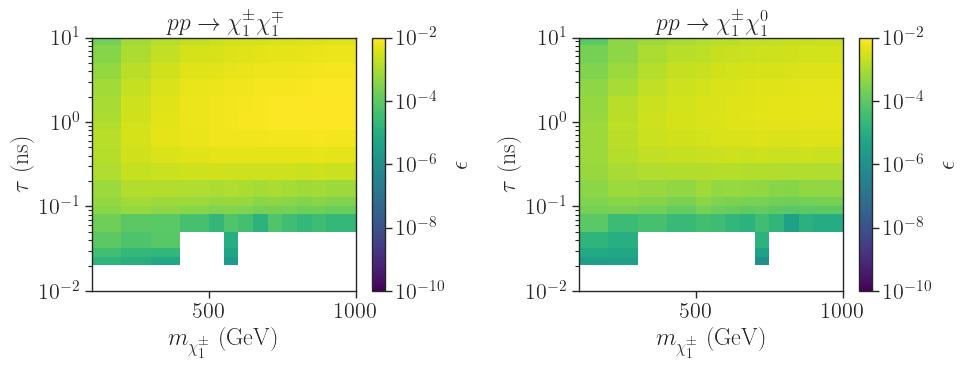

In [18]:
fig,axList =plt.subplots(figsize=(10,4),nrows=1,ncols=2)

labels = [r'$p p \to \chi_1^\pm \chi_1^\mp$',r'$p p \to \chi_1^\pm \chi_1^0$']
for ax,df,label in zip(axList,[df_c1c1,df_c1n1],labels):
    x = df['mLLP']
    y = df['tau_ns']
    z = df['EWK SR']

    # p = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-4,min(z)),vmax=max(z)))
    counts, xedges, yedges, im = ax.hist2d(x,y,bins=[sorted(x),sorted(y)],weights=z, cmap='viridis',
                                           norm=LogNorm(vmin=1e-10,vmax=1e-2))

    
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(label)

# cbar_ax = fig.add_axes([0.99, 0.25, 0.01, 0.6])
# fig.colorbar(p,label=r'$\epsilon$',cax=cbar_ax)
plt.tight_layout()
plt.show()

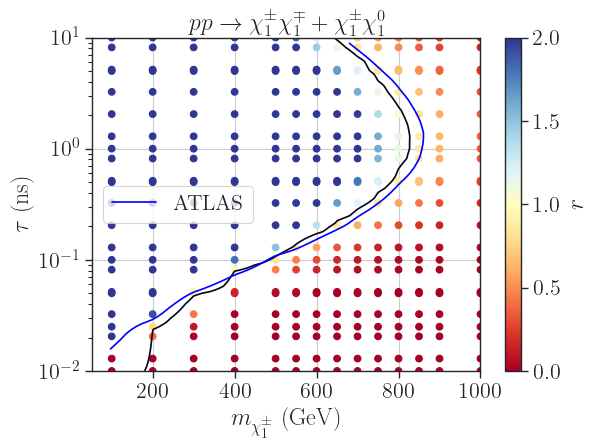

In [35]:
labels = [r'$p p \to \chi_1^\pm \chi_1^\mp$',r'$p p \to \chi_1^\pm \chi_1^0$']
x = df_comb['mLLP']
y = df_comb['tau_ns']
z = df_comb['r']

plt.scatter(x,y,c=z,cmap=cm,vmin=0,vmax=2.0)
    
plt.yscale('log')
plt.ylabel(r'$\tau$ (ns)')
plt.xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
plt.colorbar(label=r'$r$')

plt.title(r'$p p \to \chi_1^\pm \chi_1^\mp + \chi_1^\pm \chi_1^0$')

grid_x, grid_y = np.linspace(x.min(), x.max(), 1000), np.linspace(y.min(), y.max(), 1000)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)
grid_z = griddata((x, y), z, (grid_x, grid_y), method='linear')
grid_z_smooth = ndimage.gaussian_filter(grid_z, sigma=1.0)
plt.contour(grid_x, grid_y, grid_z_smooth, levels=[1.0])

plt.plot(atlas_official[:,0],atlas_official[:,1],color='blue',label='ATLAS')

# cbar_ax = fig.add_axes([0.99, 0.25, 0.01, 0.6])
# fig.colorbar(p,label=r'$\epsilon$',cax=cbar_ax)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

### Check point

In [20]:
mLLP = 900.0
tau = 1.3
eff_c1c1 =float(df_c1c1.query(f'mLLP == {mLLP} and abs(tau_ns-{tau}) < 0.01').iloc[0]['EWK SR'])
eff_c1n1 =float(df_c1n1.query(f'mLLP == {mLLP} and abs(tau_ns-{tau}) < 0.01').iloc[0]['EWK SR'])
# eff_c1c1 = 0.01007
# eff_c1n1 = 0.004895
xsecs_c1c1 = np.genfromtxt('xsec_13TeV_pp2chgchg_fb.csv',delimiter=',',names=True)
xsecs_c1n1 = np.genfromtxt('xsec_13TeV_pp2chgn1_fb.csv',delimiter=',',names=True)
im = np.argmin(np.abs(xsecs_c1c1['mass']-mLLP))
xsec_c1c1,xsec_c1c1_error = xsecs_c1c1['xsec'][im],xsecs_c1c1['unc'][im]
im = np.argmin(np.abs(xsecs_c1n1['mass']-mLLP))
xsec_c1n1,xsec_c1n1_error = xsecs_c1n1['xsec'][im],xsecs_c1n1['unc'][im]

# Shift xsecs by 1sigm
# xsec_c1c1 = xsec_c1c1-xsec_c1c1_error
# xsec_c1n1 = xsec_c1n1-xsec_c1n1_error
xsec_tot = xsec_c1c1+xsec_c1n1
eff_res = (eff_c1c1*xsec_c1c1 + eff_c1n1*xsec_c1n1)/xsec_tot
sigma_UL_atlas_fb = 0.037 # Limit from https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/SUSY-2018-19/tab_08.png
print(f"Effective efficiency = {eff_res:1.3e}")
print(f"Total xsec (fb) = {xsec_tot:1.3e}")
print(f"Visible xsec (fb) = {xsec_tot*eff_res:1.3e}")
print(f"r = {xsec_tot*eff_res/sigma_UL_atlas_fb:1.2f}")


Effective efficiency = 6.451e-03
Total xsec (fb) = 3.650e+00
Visible xsec (fb) = 2.354e-02
r = 0.64


In [21]:
eff_res*0.00417688*1e3

0.026944372713536804

In [22]:
0.0492823

0.0492823